# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraies Loaded Boss✅")

Libraies Loaded Boss✅


# **Data Exploration**

## *Load The Data*

In [2]:
File_path = input("Enter The File Path: ").replace('\\','\\')

df = pd.read_csv(File_path)
print('Data Loaded Successfully✅')

Data Loaded Successfully✅


## *Data Exploration*

In [3]:
# Data have 50k entry with 24 coloums
df.shape

(50000, 24)

In [4]:
# Transpose the data for better reading
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
transaction_id,4784,28779,37597,44058,49115,10408,2620,3378,13924,29946
customer_id,CUST8189,CUST6564,CUST2413,CUST8973,CUST4060,CUST4547,CUST2407,CUST5476,CUST5131,CUST1117
customer_name,SIMRAN DAS,Nikhil Reddy,Shreya Chopra,Arjun Joshi,Pooja Joshi,Siddharth Das,Priya Das,Zara Chopra,sneha singh,Riya Iyer
age,NaN,13,NaN,27,150,25,150,17,23,24
age_group,Young Adult (18-24),Young Adult (18-24),NaN,Young Adult (18-24),Young Adult (18-24),Young Adult (18-24),Young Adult (18-24),Young Adult (18-24),Adult (25-30),Young Adult (18-24)
city,Kolkata,Mumbai,Pune,Chennai,Bangalore,Mumbai,Hyderabad,Lucknow,Jaipur,Bangalore
email,simran.das@gmail.com,NaN,shreya.chopra@gmail.com,NaN,pooja.joshi@gmail.com,siddharth.das@gmail.com,priya.das@@gmail.com,zara.chopra@gmail.com,sneha.singh@gmail.com,NaN
phone,NaN,9025371511,9779267699,9966018593,971833,9685329623,9066815814,9903006244,99582-83857,9838348029
manga_title,DR. STONE,One Punch Man,DEMON SLAYER,Death Note,The Promised Neverland,One Punch Man,One Punch Man,Black Clover,Mob Psycho 100,Chainsaw Man
volume_no,23.0,3.0,17.0,14.0,16.0,35.0,38.0,1.0,10.0,2.0


In [5]:
df.tail(10).T

,49990,49991,49992,49993,49994,49995,49996,49997,49998,49999
transaction_id,13278,6571,37752,5877,40272,11641,19165,35949,42242,7566
customer_id,CUST7482,CUST7829,CUST4657,CUST8558,CUST1143,CUST9704,CUST8459,CUST4192,CUST1189,CUST8347
customer_name,Divya Patel,Harsh Joshi,Shreya Shah,Karan Malhotra,Harsh Shah,Pooja Verma,Vikram Das,Amit Gupta,AMIT SINGH,Nikhil Reddy
age,30,27,-27,18,20,24,17,30,28,30
age_group,Young Adult (18-24),Young Adult (18-24),Adult (25-30),Young Adult (18-24),Teen (13-17),Adult (25-30),Teen (13-17),Adult (25-30),Adult (25-30),Young Adult (18-24)
city,Kolkata,Pune,Kolkata,Bangalore,Ahmedabad,Lucknow,Mumbai,Mumbai,Delhi,Pune
email,divya.patel@gmail.com,harsh.joshi@gmail.com,shreya.shah@gmail.com,karan.malhotra@gmail.com,harsh.shah@gmail.com,pooja.vermagmail.com,vikram.das@gmail.com,amit.gupta@gmail.com,amit.singh@gmail,nikhil.reddy@gmail.com
phone,92811-73105,9727005035,9005758089,NaN,9876829355,NaN,9709716982,9678982355,9831289524,9605167734
manga_title,Spy x Family,Dr. Stone,Attack on Titan,One Piece,Naruto,Fairy Tail,Fullmetal Alchemist,Vinland Saga,Fairy Tail,BLEACH
volume_no,NaN,21.0,-37.0,NaN,36.0,34.0,13.0,9.0,13.0,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    50000 non-null  int64  
 1   customer_id       49007 non-null  str    
 2   customer_name     50000 non-null  str    
 3   age               47504 non-null  str    
 4   age_group         47992 non-null  str    
 5   city              50000 non-null  str    
 6   email             46987 non-null  str    
 7   phone             47508 non-null  str    
 8   manga_title       50000 non-null  str    
 9   volume_no         47557 non-null  float64
 10  genre             50000 non-null  str    
 11  format            48068 non-null  str    
 12  platform          48018 non-null  str    
 13  payment_method    48030 non-null  str    
 14  unit_price        47472 non-null  str    
 15  quantity          47417 non-null  float64
 16  total_amount      47396 non-null  str    
 17  cust

In [7]:
#Drop the 50%> NaN values col (Optional)
print('NaN Value % in col: ')
print(round((df.isna().sum()/df.count())*100,2))

NaN Value % in col: 


transaction_id       0.00
customer_id          2.03
customer_name        0.00
age                  5.25
age_group            4.18
city                 0.00
email                6.41
phone                5.25
manga_title          0.00
volume_no            5.14
genre                0.00
format               4.02
platform             4.13
payment_method       4.10
unit_price           5.33
quantity             5.45
total_amount         5.49
customer_rating      8.85
purchase_date       10.99
delivery_days        5.30
is_returned          4.34
membership_tier     20.67
discount_percent     4.05
coupon_used         68.22
dtype: float64


In [8]:
print("Duplicates in the Data is",df.duplicated().sum())

Duplicates in the Data is 943


# **Data Cleaning**

In [51]:
df_copy = df.copy()
print('Copy created')

Copy created


## *Data Type Correction and Neccesory steps*

In [ ]:
# Customer name column
replacements = {'@':'a','3':'e','0':'o'}

df_copy['customer_name'] = (
    df_copy['customer_name']
    .replace(replacements, regex=True)
    .str.strip()
    .str.title())



# Age Column
replacements = {'years':'','unknown':np.nan}
for char, replacement in replacements.items():
    df_copy['age'] = df_copy['age'].replace(char,replacement,regex=True).str.strip()
df_copy['age'] = df_copy['age'].astype('float')



#Age group
unknown = df_copy['age_group'].unique().tolist()
valid = ['Young Adult (18-24)','Adult (25-30)','Teen (13-17)']
to_replace = {item: 'Unknown' for item in unknown if item not in valid}
df_copy['age_group'] = df_copy['age_group'].replace(to_replace)
df_copy = df_copy[df_copy['age_group'] != '-']



# City Column
df_copy['city'] = df_copy['city'].str.strip().str.title()
replacements = {'Dlhi':'Delhi','Chenna':'Chennai','Bangalroe':'Bangalore'}
for char,replacement in replacements.items():
    df_copy['city'] = df_copy['city'].replace(char,replacement)
    
    

# Email Column
df_copy['email'] = df_copy['email'].replace('@@','@',regex=True)
df_copy['email'] = df_copy['email'].str.strip()


# Phone Column
df_copy['phone'] = df_copy['phone'].str.replace(r'\+91|-|\s', '', regex=True)
df_copy.loc[(df_copy['phone'].str.len() != 10),'phone'] = 'Unknown'



# Manga title Column
df_copy['manga_title'] = (
    df_copy['manga_title']
    .str.strip()
    .str.lower()
)

df_copy['manga_title'] = (
    df_copy['manga_title']
    .str.replace(r'0', 'o', regex=True)
    .str.replace(r'@', 'a', regex=True)
    .str.replace(r'3', 'e', regex=True)
)


mapping = {
    'narut': 'naruto',
    'narutoo': 'naruto',
    'narut0': 'naruto',

    'one piec': 'one piece',
    'one piecee': 'one piece',

    'attack on tita': 'attack on titan',
    'attack on titann': 'attack on titan',

    'demon slaye': 'demon slayer',
    'dem0n slayer': 'demon slayer',

    'tokyo ghou': 'tokyo ghoul',
    't0kyo gh0ul': 'tokyo ghoul',

    'black clove': 'black clover',
    'black cl0ver': 'black clover',

    'chainsaw ma': 'chainsaw man',

    'mob psycho 1o': 'mob psycho 100',
    'mob psycho 10': 'mob psycho 100',
    'm0b psych0 100': 'mob psycho 100',

    'dr. ston': 'dr. stone',
    'dr. st0ne': 'dr. stone',

    'fullmetal alchemis': 'fullmetal alchemist',

    'death not': 'death note',
    'death n0te': 'death note',

    'jujutsu kaise': 'jujutsu kaisen',

    'vinland sag': 'vinland saga',

    'fairy tai': 'fairy tail',

    'bleac': 'bleach',

    'hunter x hunte': 'hunter x hunter',

    'my hero academi': 'my hero academia',
    'my her0 academia': 'my hero academia',

    'sword art onlin': 'sword art online',
    'sw0rd art online': 'sword art online',

    'the promised neverlan': 'the promised neverland',
    'the pr0mised neverland': 'the promised neverland',

    'berser': 'berserk',

    'haikyuu': 'haikyu',
    'haikyuu ': 'haikyu',

    "jojo's bizarre adventur": "jojo's bizarre adventure",
    "j0j0's bizarre adventure": "jojo's bizarre adventure"
}

df_copy['manga_title'] = df_copy['manga_title'].replace(mapping)

df_copy['manga_title'] = df_copy['manga_title'].str.title()

final_fix = {
    'Mob Psycho 1Oo': 'Mob Psycho 100',
    'One Punch Ma': 'One Punch Man',
    'Spy X Famil': 'Spy X Family',
    'Dragon Ball': 'Dragon Ball Z'
}

df_copy['manga_title'] = df_copy['manga_title'].replace(final_fix)

df_copy['manga_title'] = df_copy['manga_title'].str.replace(r"'S", "'s", regex=True)

df_copy['manga_title'] = df_copy['manga_title'].str.strip()



# Volume Column
df_copy.loc[df_copy['volume_no'] > 100, 'volume_no'] = np.nan
df_copy.loc[df_copy['volume_no'] < 0, 'volume_no'] = np.nan




# Genre Column
df_copy['genre'] = df_copy['genre'].str.strip().str.title()
replacements = {'Acton':'Action','Isekkai':'Isekai','Shonnen':'Shonen','Shojo':'Shoujo'}
for char,replacement in replacements.items():
    df_copy['genre'] = df_copy['genre'].replace(char,replacement)
    
    
# Payment, Platform, Format, Membership Tier Column
columns = ['payment_method','platform','format','membership_tier']
for items in columns:
    df_copy[items] = (
        df_copy[items]
        .str.strip()
        .str.title()
        .replace(['-','None','Na'], 'Unknown')
        .fillna('Unknown')
)
    
    
    
# Price Column
df_copy['unit_price'] = df_copy['unit_price'].replace(['Rs.','/-','₹ '],'',regex=True).astype('float')
df_copy.loc[df_copy['unit_price'] > 1599, 'unit_price'] = np.nan
df_copy.loc[df_copy['unit_price'] <= 0, 'unit_price'] = np.nan
df_copy['unit_price'] = df_copy['unit_price'].fillna(round(df_copy['unit_price'].median(),2))



# Quantity Column
df_copy.loc[df_copy['quantity'] > 10, 'quantity'] = np.nan
df_copy.loc[df_copy['quantity'] <= 0, 'quantity'] = np.nan
df_copy['quantity'] = df_copy['quantity'].fillna(round(df_copy['quantity'].median(),0))



# Total Amount Column
df_copy['total_amount'] = df_copy['total_amount'].replace(['Rs.','/-','₹ '],'',regex=True).astype('float')
df_copy['total_amount'] = (df_copy['unit_price'])*(df_copy['quantity'])




# Rating Column
df_copy['customer_rating'] = df_copy['customer_rating'].round(2)
df_copy.loc[df_copy['customer_rating']<0,'customer_rating'] = np.nan
df_copy.loc[df_copy['customer_rating']>10,'customer_rating'] = np.nan
df_copy['customer_rating'] = df_copy['customer_rating'].fillna(round(df_copy['customer_rating'].median(),2))




# Date Column
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    df_copy['purchase_date'] = pd.to_datetime(
        df_copy['purchase_date'],
        errors='coerce',
        dayfirst=True,
        utc=True
    )



# Delivery Time Column
df_copy.loc[df_copy['delivery_days'] > 10, 'delivery_days'] = np.nan
df_copy.loc[df_copy['delivery_days'] <= 0, 'delivery_days'] = np.nan
df_copy['delivery_days'] = df_copy['delivery_days'].fillna(round(df_copy['delivery_days'].median(),0))



# Returend Column
column = ['coupon_used','is_returned']
for items in column:
    df_copy[items] = df_copy[items].str.strip().str.title().replace(['False','Na','0'],'No')
    df_copy[items] = df_copy[items].str.strip().str.title().replace(['1','True'],'Yes')
    df_copy[items] = df_copy[items].str.strip().str.title().replace(['-','None'],'Unknown')
    df_copy[items] = df_copy[items].fillna('Unknown')

# Discount Column
df_copy['discount_percent'] = df_copy['discount_percent'].str.strip().str.title().replace(['-','None','Na','Unknown'], 0).fillna(0).astype('float')

## **Save The clean Data**

In [33]:
save_path = input('Enter the save Path for th file: ').replace('\\','\\')
df_copy.to_csv(f'{save_path}//clean_data.csv')

## **NaN Values**

In [53]:
print('NaN values Before: ')
print(df_copy.isna().sum())
df_copy['customer_id'] = df_copy['customer_id'].fillna('Unknown')
df_copy['age'] = df_copy['age'].fillna(round(df_copy['age'].median(),2))
df_copy['email'] = df_copy['email'].fillna('Unknown')
df_copy['volume_no'] = df_copy['volume_no'].fillna(round(df_copy['volume_no'].median(),2))
df_copy['purchase_date'] = df_copy['purchase_date'].fillna(df_copy['purchase_date'].median())
print('NaN values After: ')
print(df_copy.isna().sum())


NaN values Before: 
transaction_id         0
customer_id          993
customer_name          0
age                 3529
age_group              0
city                   0
email               3013
phone                  0
manga_title            0
volume_no           6462
genre                  0
format                 0
platform               0
payment_method         0
unit_price             0
quantity               0
total_amount           0
customer_rating        0
purchase_date       4950
delivery_days          0
is_returned            0
membership_tier        0
discount_percent       0
coupon_used            0
dtype: int64
NaN values After: 
transaction_id      0
customer_id         0
customer_name       0
age                 0
age_group           0
city                0
email               0
phone               0
manga_title         0
volume_no           0
genre               0
format              0
platform            0
payment_method      0
unit_price          0
quantity          

In [55]:
print(f'Duplicates values in the data is {df_copy.duplicated().sum()}')
df_copy.drop_duplicates(inplace=True)
print(f'Duplicates values in the data after dropping them is {df_copy.duplicated().sum()}')

Duplicates values in the data is 1422
Duplicates values in the data after dropping them is 0


# **EDA**

**Q1. What are the top 5 best-selling manga titles by total revenue?**

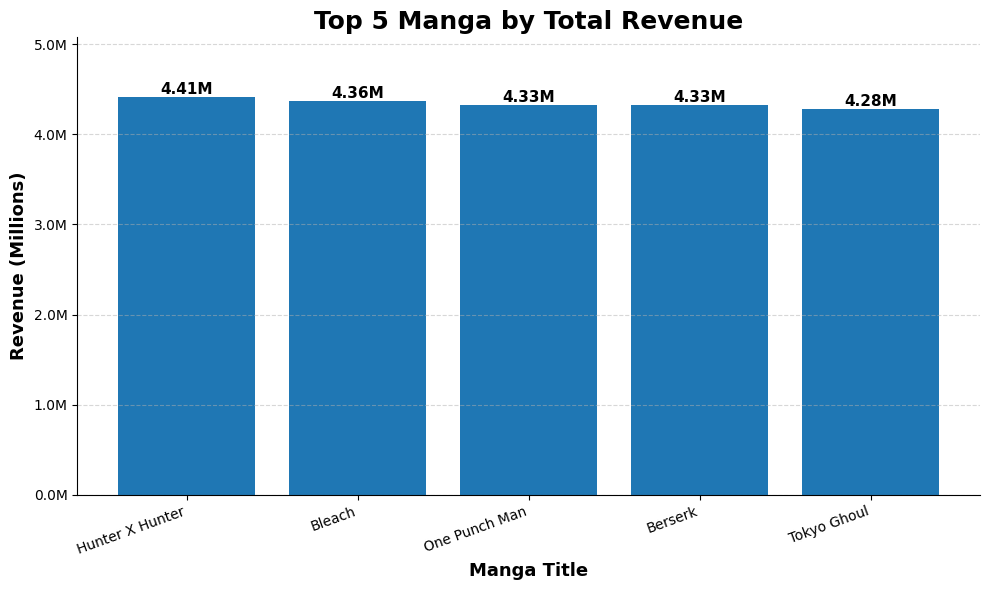

In [61]:
import matplotlib.ticker as mtick

plot = (
    df_copy.groupby('manga_title')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head()
)

plt.figure(figsize=(10,6))

bars = plt.bar(plot.index, plot.values)


plt.xticks(rotation=20, ha='right') 

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1_000_000:.2f}M",
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold'
    )

plt.title('Top 5 Manga by Total Revenue', fontsize=18, weight='bold')
plt.ylabel('Revenue (Millions)', fontsize=13, weight='bold')
plt.xlabel('Manga Title', fontsize=13, weight='bold')

ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.ylim(0, plot.max() * 1.15)

plt.tight_layout()
plt.show()

**Q2. Which city generates the most sales?**

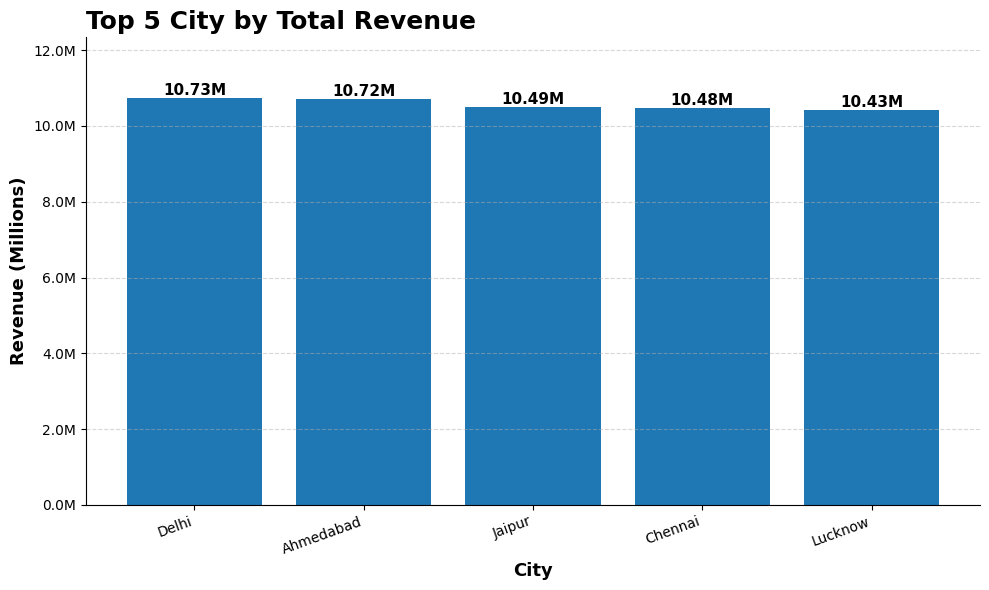

In [63]:
import matplotlib.ticker as mtick

plot = (
    df_copy.groupby('city')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head()
)

plt.figure(figsize=(10,6))

bars = plt.bar(plot.index, plot.values)


plt.xticks(rotation=20, ha='right') 

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1_000_000:.2f}M",
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold'
    )

plt.title('Top 5 City by Total Revenue', fontsize=18, weight='bold',loc='left')
plt.ylabel('Revenue (Millions)', fontsize=13, weight='bold')
plt.xlabel('City', fontsize=13, weight='bold')

ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.ylim(0, plot.max() * 1.15)

plt.tight_layout()
plt.show()

**Q3. What is the most popular format? (Paperback, Box Set etc)**

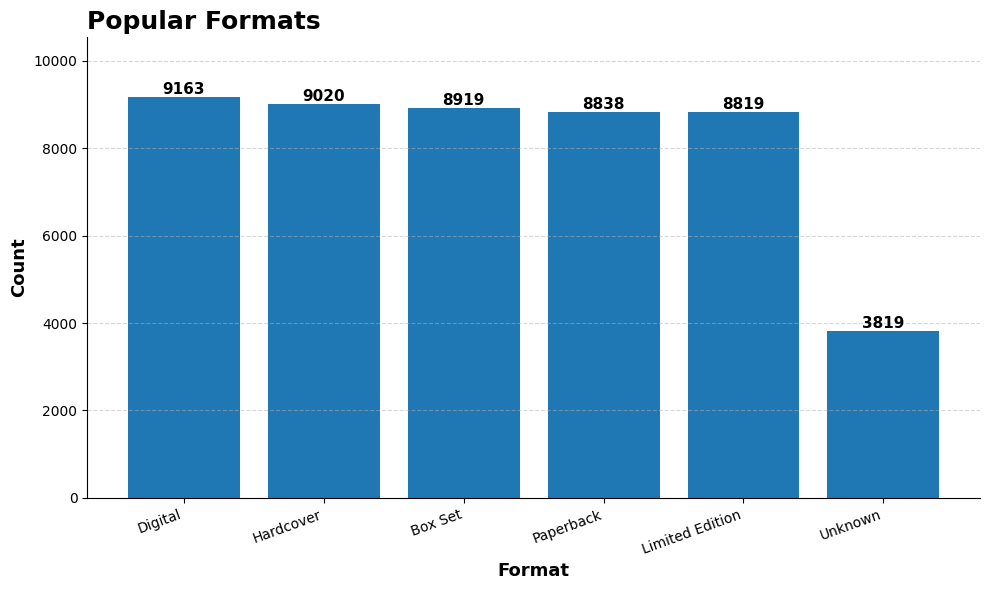

In [71]:
import matplotlib.ticker as mtick

plot = df_copy['format'].value_counts()

plt.figure(figsize=(10,6))

bars = plt.bar(plot.index, plot.values)


plt.xticks(rotation=20, ha='right') 

ax = plt.gca()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height}",
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold'
    )

plt.title('Popular Formats', fontsize=18, weight='bold',loc='left')
plt.ylabel('Count', fontsize=13, weight='bold')
plt.xlabel('Format', fontsize=13, weight='bold')

ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.ylim(0, plot.max() * 1.15)

plt.tight_layout()
plt.show()

**Q4. Which genre has the highest average customer rating?**

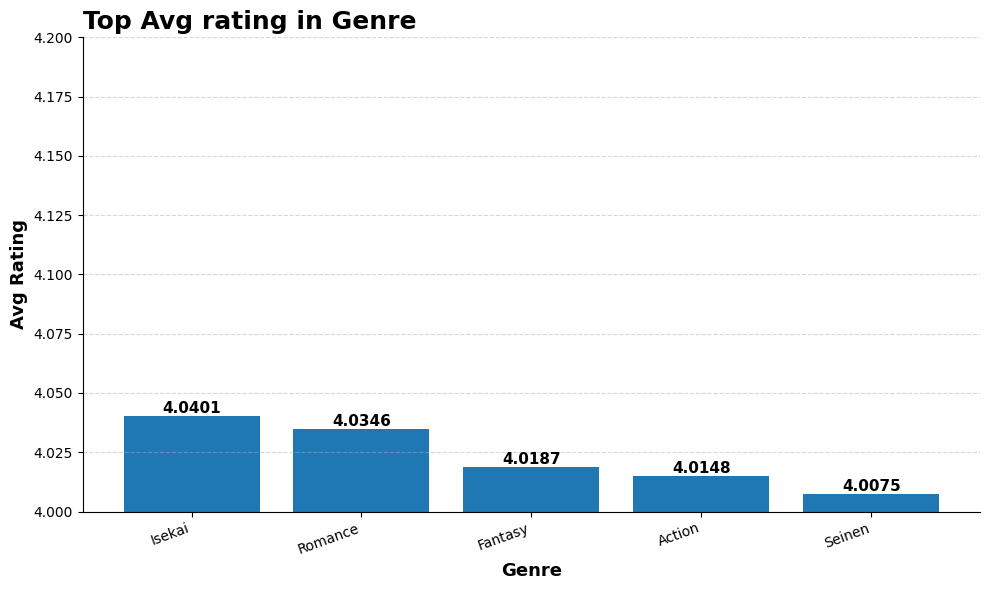

In [90]:
plot = df_copy.groupby('genre')['customer_rating'].mean().round(4).sort_values(ascending=False).head()

plt.figure(figsize=(10,6))

bars = plt.bar(plot.index, plot.values)


plt.xticks(rotation=20, ha='right') 

ax = plt.gca()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height}",
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold'
    )

plt.title('Top Avg rating in Genre', fontsize=18, weight='bold',loc='left')
plt.ylabel('Avg Rating', fontsize=13, weight='bold')
plt.xlabel('Genre', fontsize=13, weight='bold')

ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.ylim(4, 4.2)

plt.tight_layout()
plt.show()

**Q5. Do coupon users spend more or less than non-coupon users on average?**

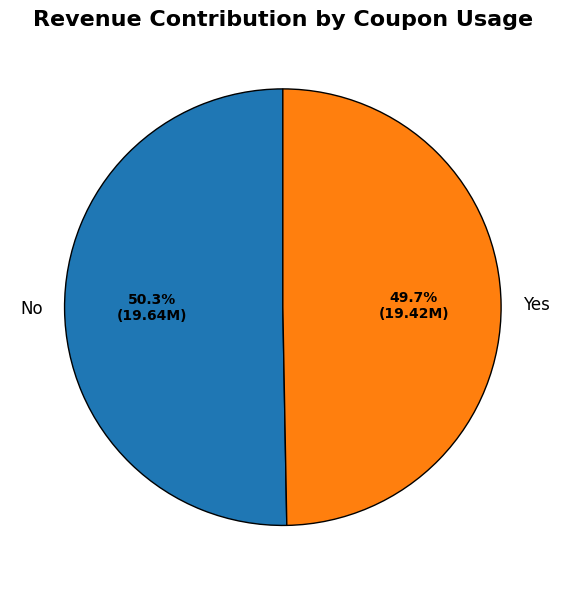

In [95]:
df_work = df_copy[df_copy['coupon_used'] != 'Unknown']
plot = df_work.groupby('coupon_used')['total_amount'].sum()

# Convert to millions
plot_m = plot / 1_000_000

plt.figure(figsize=(6,6))

wedges, texts, autotexts = plt.pie(
    plot_m,
    labels=plot.index,
    autopct=lambda pct: f"{pct:.1f}%\n({pct/100 * plot_m.sum():.2f}M)",
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

# Style text
for text in texts:
    text.set_fontsize(12)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

plt.title('Revenue Contribution by Coupon Usage', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

**Q6. Which membership tier generates the most total revenue?**

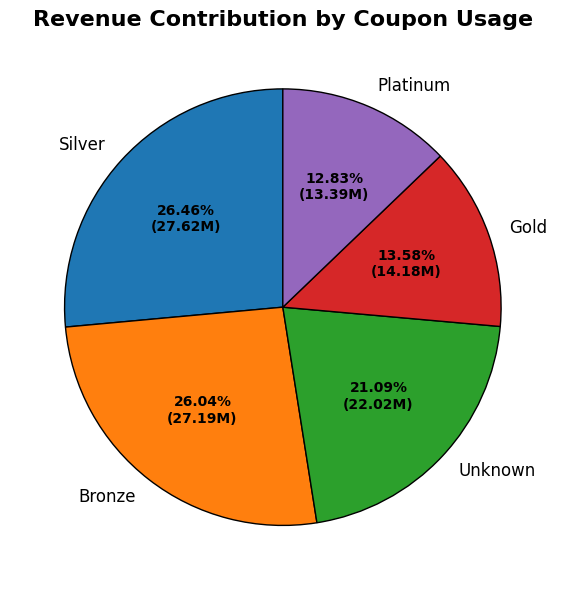

In [99]:
plot = df_copy.groupby('membership_tier')['total_amount'].sum().sort_values(ascending=False)

# Convert to millions
plot_m = plot / 1_000_000

plt.figure(figsize=(6,6))

wedges, texts, autotexts = plt.pie(
    plot_m,
    labels=plot.index,
    autopct=lambda pct: f"{pct:.2f}%\n({pct/100 * plot_m.sum():.2f}M)",
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

# Style text
for text in texts:
    text.set_fontsize(12)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

plt.title('Revenue Contribution by Coupon Usage', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

**Q7. What is the average delivery days by platform?**

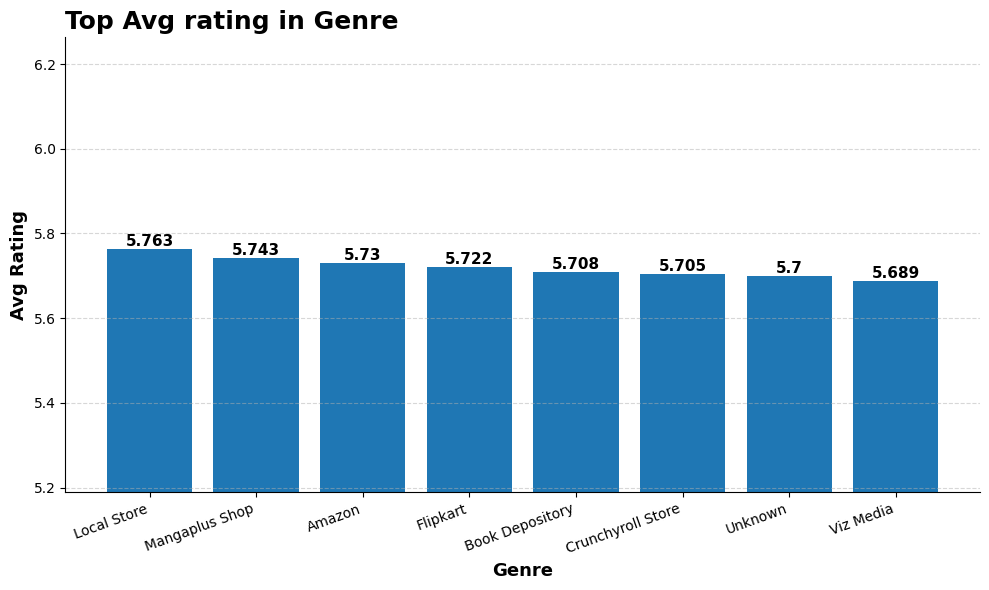

In [107]:
plot = df_copy.groupby('platform')['delivery_days'].mean().round(3).sort_values(ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(plot.index, plot.values)


plt.xticks(rotation=20, ha='right') 

ax = plt.gca()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height}",
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold'
    )

plt.title('Top Avg rating in Genre', fontsize=18, weight='bold',loc='left')
plt.ylabel('Avg Rating', fontsize=13, weight='bold')
plt.xlabel('Genre', fontsize=13, weight='bold')

ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.ylim(plot.min()-0.5, plot.max()+0.5)

plt.tight_layout()
plt.show()

**Q8. What is the return rate by genre — which genre gets returned most?**

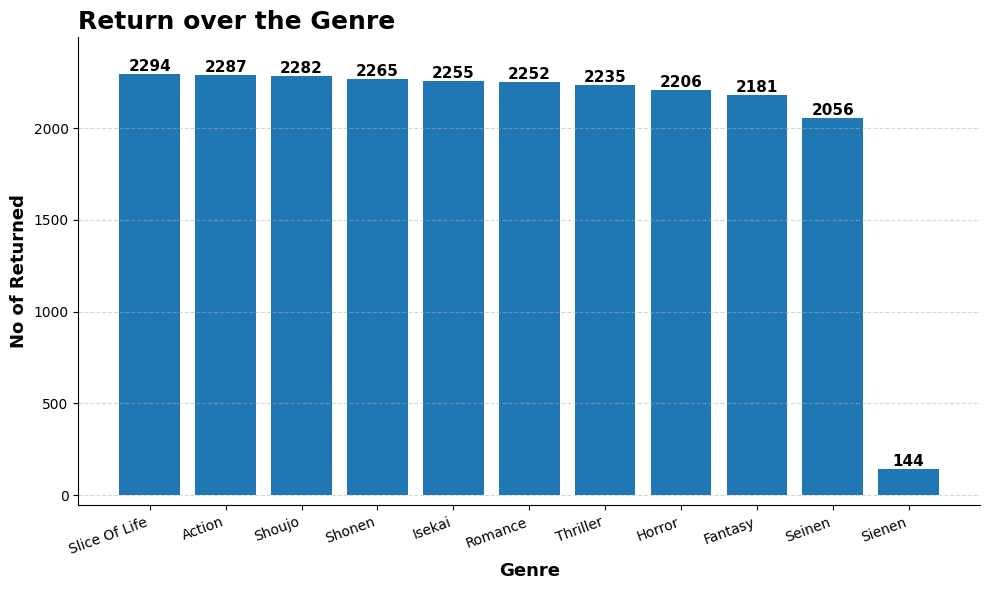

In [115]:
df_work = df_copy[df_copy['is_returned']=='Yes']
plot = df_work.groupby('genre')['is_returned'].count().sort_values(ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(plot.index, plot.values)


plt.xticks(rotation=20, ha='right') 

ax = plt.gca()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height}",
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold'
    )

plt.title('Return over the Genre', fontsize=18, weight='bold',loc='left')
plt.ylabel('No of Returned', fontsize=13, weight='bold')
plt.xlabel('Genre', fontsize=13, weight='bold')

ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.ylim(plot.min()-200, plot.max()+200)

plt.tight_layout()
plt.show()

**Q9. Do higher discounts lead to lower ratings? (scatter plot + correlation)**

Correlation between Discount and Rating: -0.002


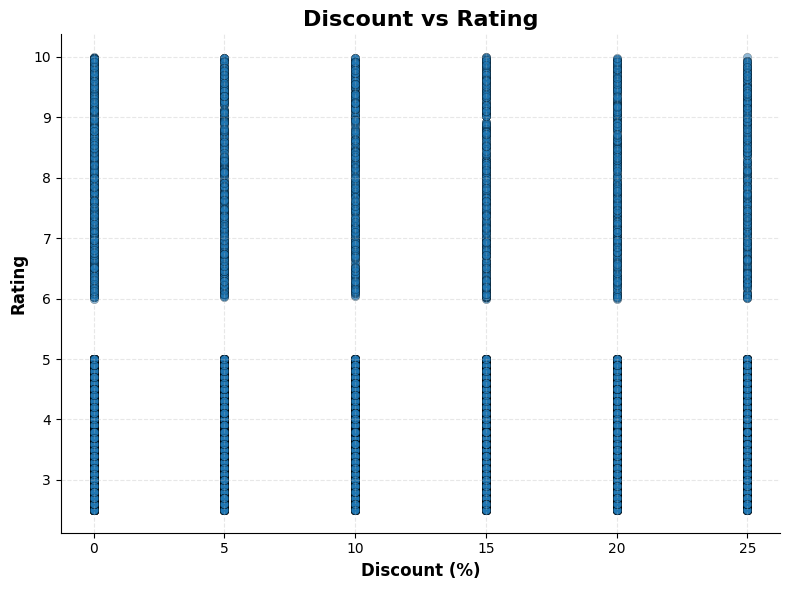

In [117]:
corr = df_copy[['discount_percent','customer_rating']].corr().iloc[0,1]
print(f"Correlation between Discount and Rating: {corr:.3f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_copy['discount_percent'],
    df_copy['customer_rating'],
    alpha=0.5,
    edgecolors='black',
    linewidths=0.3
)

# Labels
plt.title('Discount vs Rating', fontsize=16, weight='bold')
plt.xlabel('Discount (%)', fontsize=12, weight='bold')
plt.ylabel('Rating', fontsize=12, weight='bold')

# Grid + style
ax = plt.gca()
ax.spines[['top','right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Q10. Which age group buys the most manga and spends the most?**

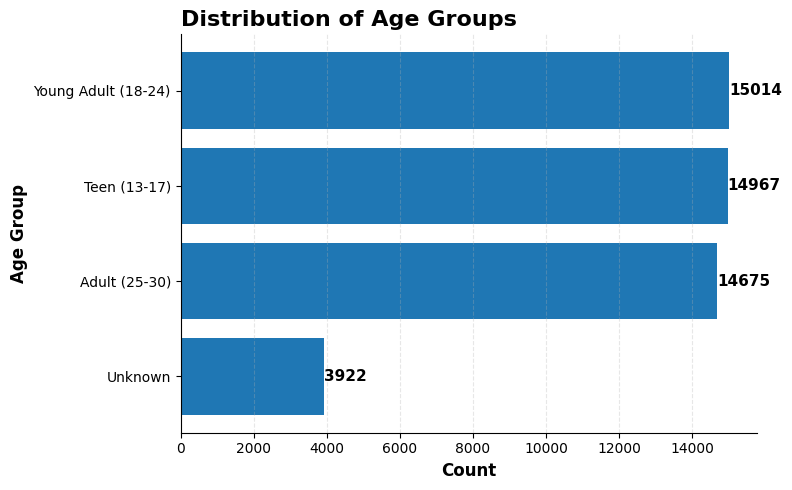

In [123]:
plot = df_copy['age_group'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))

bars = plt.barh(plot.index, plot.values)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=11,
        weight='bold'
    )

# Styling
plt.title('Distribution of Age Groups', fontsize=16, weight='bold',loc='left')
plt.xlabel('Count', fontsize=12, weight='bold')
plt.ylabel('Age Group', fontsize=12, weight='bold')

ax = plt.gca()
ax.spines[['top','right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()